In [101]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

from collections import defaultdict
#import tensorflow as tf
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import LSTM, Dense

In [188]:
# --- 1. Load data ---
ticker = "^GSPC"
sp500 = yf.Ticker(ticker)
data = sp500.history(period="30y")["Close"]
data = data.dropna()
train_size = int(len(data) * 0.85)
base_train = data[0]
base_test = data[train_size]
#data = data.diff()[1:]/np.array(data[:-1])
data = np.log(data[1:] / np.array(data[:-1]))

# --- 2. Train/Test Split ---

train, test = data[:train_size], data[train_size:]

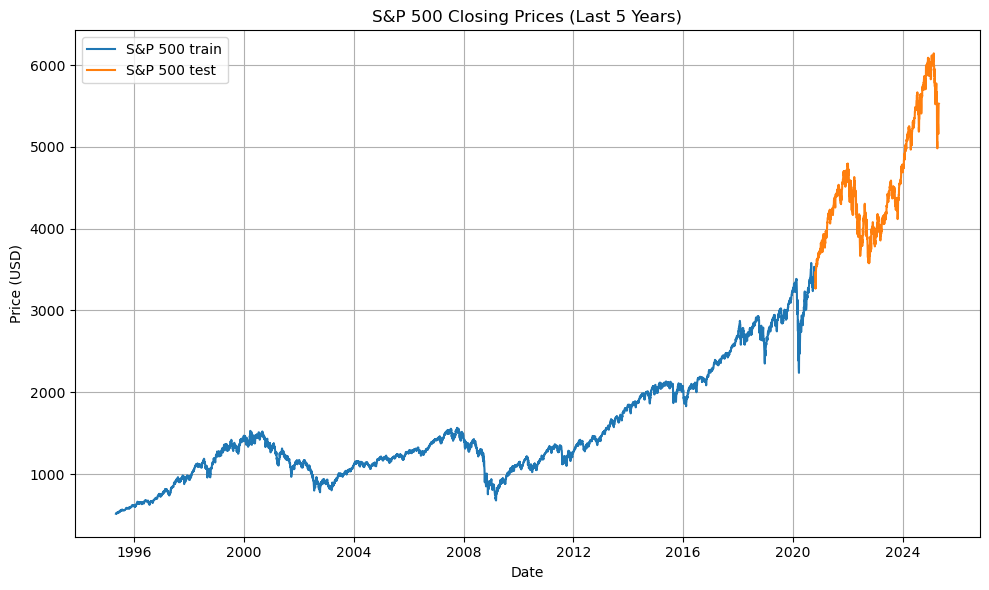

In [184]:
# Optional: Plot the closing price
plt.figure(figsize=(10, 6))
plt.plot(train.index, base_train*np.exp(np.cumsum(train)), label="S&P 500 train")
plt.plot(test.index, base_test*np.exp(np.cumsum(test)), label="S&P 500 test")
plt.title("S&P 500 Closing Prices (Last 5 Years)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()

In [122]:
arima_model = ARIMA(train, order=(5, 0, 5)).fit()
arima_pred = [arima_model.forecast(1) for i in range(1)]
arima_pred

/Users/eochoa/opt/anaconda3/envs/working/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/eochoa/opt/anaconda3/envs/working/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/eochoa/opt/anaconda3/envs/working/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/eochoa/opt/anaconda3/envs/working/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed 

[377    0.00104
 dtype: float64]

/Users/eochoa/opt/anaconda3/envs/working/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/eochoa/opt/anaconda3/envs/working/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/eochoa/opt/anaconda3/envs/working/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/eochoa/opt/anaconda3/envs/working/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregres

ARIMA RMSE: 0.0118
Exponential Smoothing RMSE: 0.0118
Random Forest RMSE: 0.0124


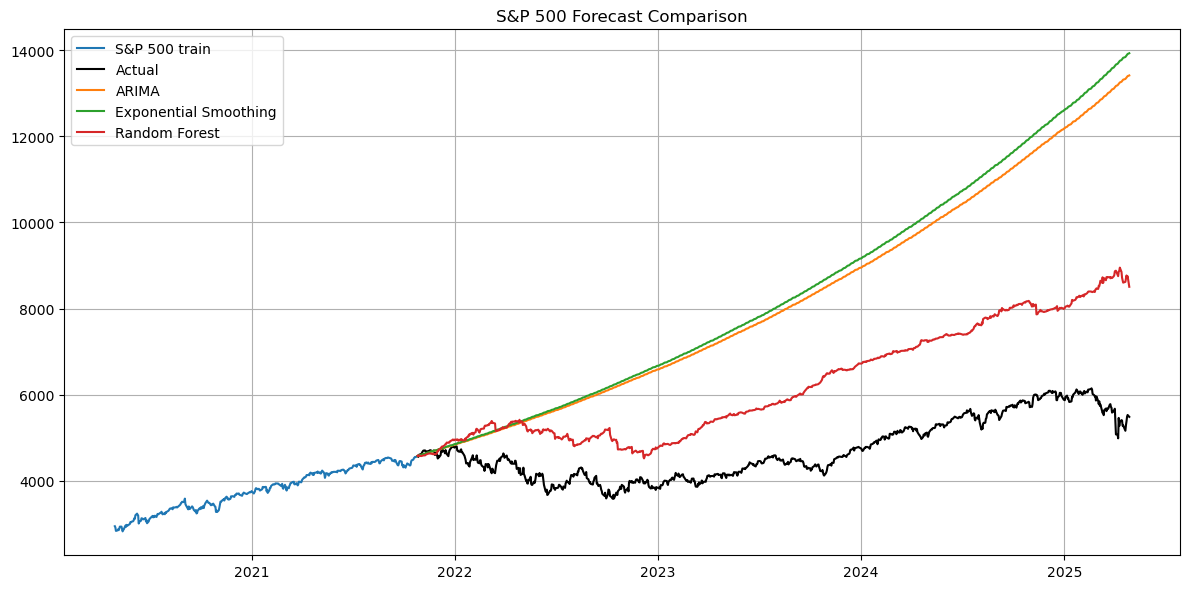

In [123]:




# --- 3. ARIMA ---
arima_model = ARIMA(train, order=(1, 0, 1)).fit()
arima_pred = arima_model.forecast(steps=len(test))
arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))

# --- 4. Exponential Smoothing ---
exp_model = ExponentialSmoothing(train, trend=None, seasonal=None).fit()
exp_pred = exp_model.forecast(len(test))
exp_rmse = np.sqrt(mean_squared_error(test, exp_pred))


# --- 5. Random Forest ---
window = 10  # lagged features
def create_lagged_df(series, window):
    df = pd.DataFrame()
    for i in range(window):
        df[f"lag_{i+1}"] = series.shift(i + 1)
    df["target"] = series.values
    return df.dropna()

rf_data = create_lagged_df(data, window)
train_rf = rf_data[:train_size - window]
test_rf = rf_data[train_size - window:]

X_train_rf, y_train_rf = train_rf.drop("target", axis=1), train_rf["target"]
X_test_rf, y_test_rf = test_rf.drop("target", axis=1), test_rf["target"]

rf_model = RandomForestRegressor()
rf_model.fit(X_train_rf, y_train_rf)
rf_pred = rf_model.predict(X_test_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test_rf, rf_pred))

# --- 7. Results ---
print(f"ARIMA RMSE: {arima_rmse:.4f}")
print(f"Exponential Smoothing RMSE: {exp_rmse:.4f}")
print(f"Random Forest RMSE: {rf_rmse:.4f}")
#print(f"LSTM RMSE: {lstm_rmse:.2f}")

# --- 8. Plot (Optional) ---
plt.figure(figsize=(12, 6))
plt.plot(train.index, base_train*np.exp(np.cumsum(train)), label="S&P 500 train")
plt.plot(test.index, base_test*np.exp(np.cumsum(test)), label="Actual", color="black")
plt.plot(test.index, base_test*np.exp(np.cumsum(arima_pred)), label="ARIMA")
plt.plot(test.index, base_test*np.exp(np.cumsum(exp_pred)), label="Exponential Smoothing")
plt.plot(test_rf.index, base_test*np.exp(np.cumsum(rf_pred)), label="Random Forest")
#plt.plot(test.index[-len(lstm_pred_rescaled):], lstm_pred_rescaled.flatten(), label="LSTM")
plt.title("S&P 500 Forecast Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Random Forest RMSE: 685.4313
Random Forest RMSE: 959.3685
Random Forest RMSE: 902.4510
Random Forest RMSE: 1333.5723


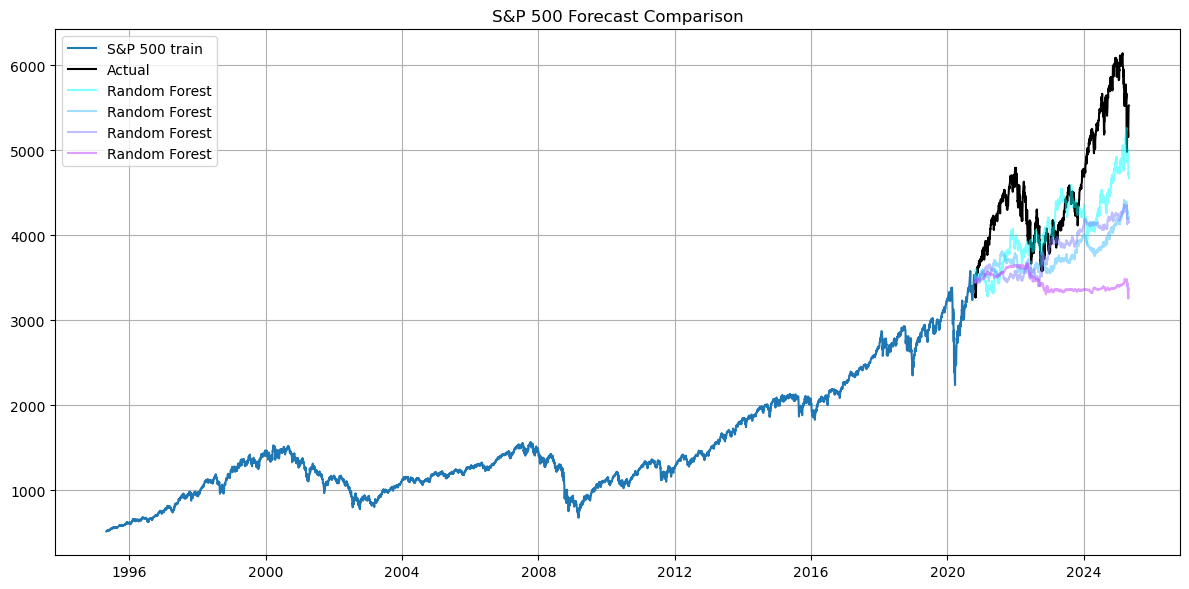

In [185]:
# --- 5. Random Forest ---
def create_lagged_df(series, window):
    df = pd.DataFrame()
    for i in range(window):
        df[f"lag_{i+1}"] = series.shift(i + 1)
    df["target"] = series.values
    return df.dropna()

#    window = 10  # lagged features

rf_list = defaultdict(list)
for window in list(range(1,4))+[30]:
    rf_data = create_lagged_df(data, window)
    train_rf = rf_data[:train_size - window]
    test_rf = rf_data[train_size - window:]

    X_train_rf, y_train_rf = train_rf.drop("target", axis=1), train_rf["target"]
    X_test_rf, y_test_rf = test_rf.drop("target", axis=1), test_rf["target"]
    n_test = y_test_rf.shape[0]
    
    rf_model = RandomForestRegressor()
    rf_model.fit(X_train_rf, y_train_rf)
    rf_pred = rf_model.predict(X_test_rf)
    rf_list['pred'].append(rf_pred)
    #rf_rmse = np.sqrt(mean_squared_error(base_test*np.exp(np.cumsum(y_test_rf)), base_test*np.exp(np.cumsum(rf_pred))))
    rf_rmse = np.sqrt(1/np.arange(1,n_test+1)*np.cumsum((base_test*np.exp(np.cumsum(y_test_rf))- base_test*np.exp(np.cumsum(rf_pred)))**2))
    rf_list['rmse'].append(rf_rmse)
    
# --- 7. Results ---
for i in range(4):
    print(f"Random Forest RMSE: {rf_list['rmse'][i][-1]:.4f}")

# --- 8. Plot (Optional) ---
plt.figure(figsize=(12, 6))
plt.plot(train.index, base_train*np.exp(np.cumsum(train)), label="S&P 500 train")
plt.plot(test.index, base_test*np.exp(np.cumsum(test)), label="Actual", color="black")
for i in range(4):
    plt.plot(test_rf.index, base_test*np.exp(np.cumsum(rf_list['pred'][i])), 
             c=mpl.colormaps['cool'](i/4),
             label="Random Forest",
             alpha=.5)
#plt.plot(test.index[-len(lstm_pred_rescaled):], lstm_pred_rescaled.flatten(), label="LSTM")
plt.title("S&P 500 Forecast Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

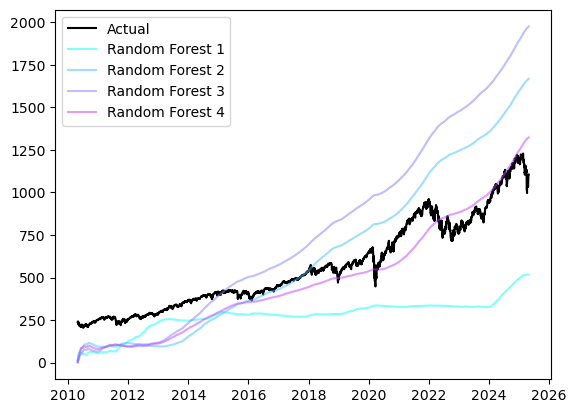

In [178]:
plt.plot(test.index, base_test*np.exp(np.cumsum(test))/5, label="Actual", color="black")
for i in range(4):
    plt.plot(rf_list['rmse'][i], 
             c=mpl.colormaps['cool'](i/4),
             label="Random Forest " + str(i+1),
             alpha=.5)
plt.legend()